# DREAM (Ecoli) boundary tracking

In [20]:
import os, pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

ROOT = ".."
EDGE = 0.20
RUNS_TO_TRY = [1, 2, 3, 4, 5]
FN_TMPL = "run{run}_cbo_unknown_dr2_boundary_EI_200_1_nonlinear.pickle"
GRAPHS = ["Size50-Ecoli1", "Size100-Ecoli1"]

VARIANTS = {
    "Non-Parent""":   "results/boundary_tracking_dream_random",
    "Parent RBF":               "results/boundary_tracking_dream_oracle",
    "Parent spherical linear":     "results/boundary_tracking_dream_oracle_spherical",
    "Parent spherical RBF": "results/boundary_tracking_dream_oracle_spherical_rbf",
}
COLORS = {"Non-Parent": "#D55E00", "Parent RBF": "#0072B2",
          "Parent spherical linear": "#009E73", "Parent spherical RBF": "#CC79A7"}

def load_runs(variant, graph):
    out = []
    for run in RUNS_TO_TRY:
        p = os.path.join(ROOT, VARIANTS[variant], graph, FN_TMPL.format(run=run))
        if os.path.exists(p):
            with open(p, "rb") as f:
                out.append((run, pickle.load(f)))
    return out

def per_intervention(r):
    rng, tp = r["Intervention_Ranges"], set(r["True_Parents"])
    rows = []
    for t, (vs, vals) in enumerate(zip(r["Intervention_Set"], r["Intervention_Value"])):
        for var, val in zip(vs, vals):
            lo, hi = rng[var]
            val = float(val)
            rows.append(dict(trial=t, var=var, value=val,
                             pos=(val - lo) / (hi - lo) if hi > lo else np.nan,
                             is_parent=var in tp))
    return pd.DataFrame(rows)

RUNS = {(v, g): load_runs(v, g) for v in VARIANTS for g in GRAPHS}
print({f"{v}|{g}": f"{len(rs)} run(s)" for (v, g), rs in RUNS.items()})

{'Non-Parent|Size50-Ecoli1': '5 run(s)', 'Non-Parent|Size100-Ecoli1': '5 run(s)', 'Parent RBF|Size50-Ecoli1': '5 run(s)', 'Parent RBF|Size100-Ecoli1': '5 run(s)', 'Parent spherical linear|Size50-Ecoli1': '5 run(s)', 'Parent spherical linear|Size100-Ecoli1': '5 run(s)', 'Parent spherical RBF|Size50-Ecoli1': '5 run(s)', 'Parent spherical RBF|Size100-Ecoli1': '5 run(s)'}


## Overall % of interventions on the boundary

In [21]:
FAMILY = "dream"
MED_TAGS = {"Size50-Ecoli1": "Size50-Ecoli1_t28",
            "Size100-Ecoli1": "Size100-Ecoli1_t66"}
MED_SOURCES = {
    "Non-ancestor": f"results/boundary_tracking_{FAMILY}_random_non_ancestor",
    "Ancestor":     f"results/boundary_tracking_{FAMILY}_random_ancestor",
}
MED_CATEGORY = {"Non-ancestor""": "non_ancestor",
                "Ancestor""": "ancestor"}
COLORS.update({"Non-ancestor""": "#E69F00", "Ancestor""": "#56B4E9"})
MED_REJECTED = []

ORACLE_DIR = {"erdos": "results/boundary_tracking_erdos_oracle",
              "dream": "results/boundary_tracking_dream_oracle",
              "gwps":  "results/boundary_tracking_gwps_oracle"}[FAMILY]
PARENT_MATCHED = "Parent"""
COLORS[PARENT_MATCHED] = COLORS["Parent"" RBF"]

def load_parent_matched(graph):
    out = []
    tag = MED_TAGS.get(graph)
    if tag is None:
        return out
    for run in RUNS_TO_TRY:
        p = os.path.join(ROOT, ORACLE_DIR, tag, FN_TMPL.format(run=run))
        if os.path.exists(p):
            with open(p, "rb") as f:
                out.append((run, pickle.load(f)))
    return out

def load_med(variant, graph):
    out = []
    tag = MED_TAGS.get(graph)
    if tag is None:
        return out
    for run in RUNS_TO_TRY:
        p = os.path.join(ROOT, MED_SOURCES[variant], tag, FN_TMPL.format(run=run))
        if not os.path.exists(p):
            continue
        with open(p, "rb") as f:
            r = pickle.load(f)
        if r.get("Node_Category") != MED_CATEGORY[variant]:
            MED_REJECTED.append((variant, tag, run, r.get("Node_Category")))
            continue
        out.append((run, r))
    return out

ALL_RUNS = dict(RUNS)
for v in MED_SOURCES:
    for g in GRAPHS:
        ALL_RUNS[(v, g)] = load_med(v, g)
for g in GRAPHS:
    ALL_RUNS[(PARENT_MATCHED, g)] = load_parent_matched(g)

def boundary_per_seed(runs):
    rows = []
    for run, r in runs:
        d = per_intervention(r)
        rows.append(dict(
            run=run,
            outer20=100 * float(((d.pos <= EDGE) | (d.pos >= 1 - EDGE)).mean()),
            target=str(r.get("Target", "?")),
            k=len(r["Intervention_Set"][0]),
        ))
    return pd.DataFrame(rows)

rows = []
for (v, g), runs in ALL_RUNS.items():
    if not runs:
        continue
    s = boundary_per_seed(runs)
    rows.append(dict(
        variant=v, graph=g, n=len(s),
        source_tag=(MED_TAGS.get(g, g)
                    if (v in MED_SOURCES or v == PARENT_MATCHED) else g),
        outer20=s.outer20.mean(), outer20_sd=s.outer20.std(ddof=0),
        target=s.target.iloc[0], k=int(s.k.iloc[0]),
    ))
bnd_tbl = pd.DataFrame(rows)

if MED_REJECTED:
    print("REJECTED (wrong Node_Category for the folder -- old unstratified runs):")
    for v, tag, run, cat in MED_REJECTED:
        print(f"  {v:22s} {tag:22s} run{run}  category={cat}")
missing = [(v, g) for v in list(MED_SOURCES) + [PARENT_MATCHED]
           for g in GRAPHS if not ALL_RUNS[(v, g)]]
if missing:
    print("\nNOT AVAILABLE (arm not run for this graph):")
    for v, g in missing:
        print(f"  {v:22s} {g}")

In [23]:
FS_XTICK = 12
FS_YLABEL = 12
FS_BAR_VALUE = 12
FS_LEGEND = 8

PLOT_GRAPHS = ["Size50-Ecoli1"]

LABELS = {
    "Parent RBF": "RBF",
    "Parent spherical linear": "Spherical Linear",
    "Parent spherical RBF": "Spherical RBF",
}

FIG_DIR = os.path.join(ROOT, "results/figures")
os.makedirs(FIG_DIR, exist_ok=True)

def boundary_figure(variants, fname=None, ref="Parent"" RBF"):
    have = [v for v in variants if ((bnd_tbl.variant == v).any() if len(bnd_tbl) else False)]
    if not have:
        print("no data for: " + ", ".join(variants))
        return
    fig, axes = plt.subplots(1, len(PLOT_GRAPHS), figsize=(1.35 * len(have) * len(PLOT_GRAPHS) + 2.2, 4.4),
                             squeeze=False, sharey=True)
    notes = []
    for ax, g in zip(axes[0], PLOT_GRAPHS):
        sub = bnd_tbl[bnd_tbl.graph == g].set_index("variant")
        present = [v for v in have if v in sub.index]
        x = np.arange(len(present)); w = 0.6
        refcfg = tuple(sub.loc[ref, ["source_tag", "k"]]) if ref in sub.index else None
        for xi, v in enumerate(present):
            row = sub.loc[v]
            odd = refcfg is not None and (row.source_tag, row.k) != refcfg
            ax.bar(xi, row.outer20, w, yerr=row.outer20_sd, capsize=3,
                   color=COLORS[v], edgecolor="white")
            ax.text(xi, row.outer20 + 3, f"{row.outer20:.0f}", ha="center",
                    fontsize=FS_BAR_VALUE)
            if odd:
                tgt = "" if row.target in ("?", "None") else f", target {row.target}"
                notes.append(f"{g}: {v} comes from {row.source_tag}{tgt}, k={row.k} "
                             f"  (vs {ref} from {refcfg[0]}, k={refcfg[1]})")
        ax.axhline(100 * 2 * EDGE, color="0.6", ls=":", lw=1.2)
        ax.set_xticks(x)
        ax.set_xticklabels([LABELS.get(v, v) for v in present],
                           rotation=0, ha="center", fontsize=FS_XTICK)
        ax.set_title(g); ax.set_ylim(0, 112)
        ax.spines[["top", "right"]].set_visible(False)
        ax.grid(axis="y", color="0.93"); ax.set_axisbelow(True)
    axes[0][0].set_ylabel("% of interventions in the outer-20% zone",
                          fontsize=FS_YLABEL)
    fig.tight_layout()
    if fname:
        fig.savefig(fname, dpi=200, bbox_inches="tight")
    plt.show()
    if notes:
        print("NOTE -- different graph configuration from the reference arm:")
        for n in dict.fromkeys(notes):
            print("  " + n)

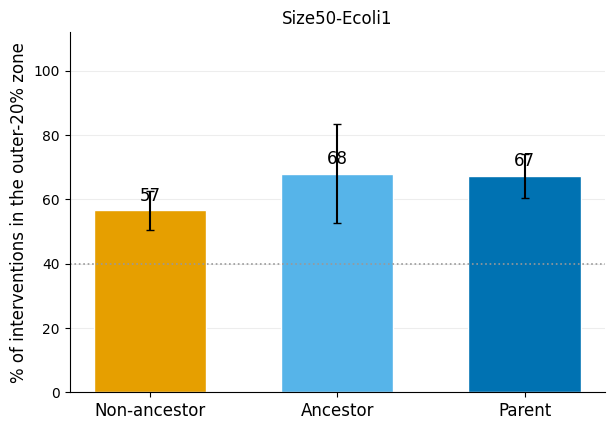

In [24]:
boundary_figure(
    ["Non-ancestor""", "Ancestor""", PARENT_MATCHED],
    ref=PARENT_MATCHED,
    fname=os.path.join(FIG_DIR, "dream_boundary_by_ancestry.pdf"),
)

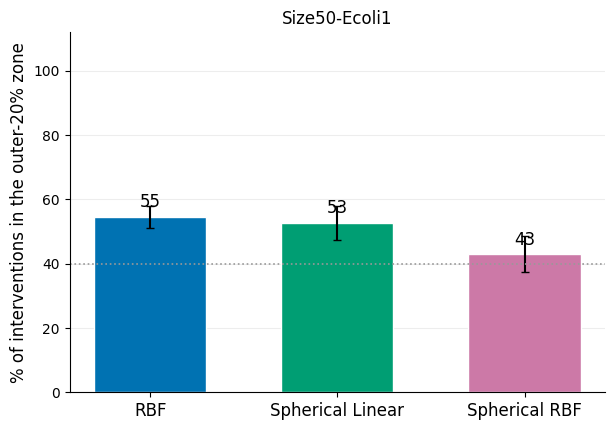

In [25]:
boundary_figure(
    ["Parent"" RBF", "Parent"" spherical linear",
     "Parent"" spherical RBF"],
    fname=os.path.join(FIG_DIR, "dream_boundary_by_kernel.pdf"),
)

## Optimisation performance by surrogate kernel

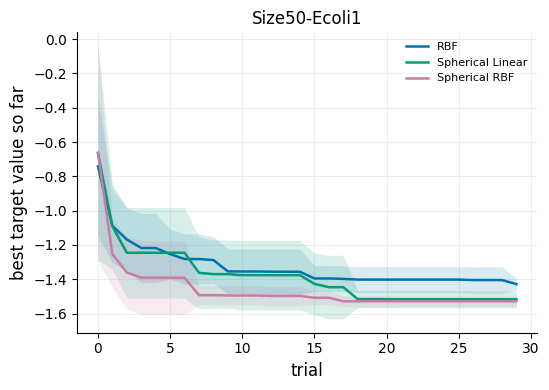

In [ ]:
KERNEL_VARIANTS = ["Parent RBF", "Parent spherical linear", "Parent spherical RBF"]

def best_y_matrix(runs):
    curves = [np.asarray(r["Best_Y"], dtype=float) for _, r in runs]
    if not curves:
        return None
    n = min(len(c) for c in curves)
    return np.vstack([c[:n] for c in curves])

def best_y_figure(variants, fname=None):
    fig, axes = plt.subplots(1, len(PLOT_GRAPHS), figsize=(5.0 * len(PLOT_GRAPHS) + 0.6, 4.0),
                             squeeze=False)
    any_data = False
    for ax, g in zip(axes[0], PLOT_GRAPHS):
        for v in variants:
            M = best_y_matrix(ALL_RUNS.get((v, g), []))
            if M is None:
                continue
            any_data = True
            t = np.arange(M.shape[1])
            m, sd = M.mean(0), M.std(0, ddof=0)
            ax.plot(t, m, color=COLORS[v], lw=1.8, label=f"{LABELS.get(v, v)}")
            if M.shape[0] > 1:
                ax.fill_between(t, m - sd, m + sd, color=COLORS[v], alpha=0.15, lw=0)
        ax.set_title(g)
        ax.set_xlabel("trial", fontsize=FS_YLABEL)
        ax.spines[["top", "right"]].set_visible(False)
        ax.grid(color="0.93"); ax.set_axisbelow(True)
        ax.legend(fontsize=FS_LEGEND, frameon=False)
    if not any_data:
        plt.close(fig)
        print("no Best_Y data for: " + ", ".join(variants))
        return
    axes[0][0].set_ylabel("best target value so far", fontsize=FS_YLABEL)
    fig.tight_layout()
    if fname:
        fig.savefig(fname, dpi=200, bbox_inches="tight")
    plt.show()

best_y_figure(KERNEL_VARIANTS,
              fname=os.path.join(FIG_DIR, "dream_best_y_by_kernel.pdf"))